# bxai
### Bayesian Feature Selection and Attribution Suite

### Load Data

In [1]:
from sklearn.datasets import load_breast_cancer

# Load Breast Cancer dataset
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
print(f"{len(X)} Rows and {len(X.columns)} Columns")

569 Rows and 30 Columns


## 1. Global Non-Linear Selection: `BayesianBorutaSHAP`

`BayesianBorutaSHAP` performs tree-based feature selection using SHAP values, replacing frequentist p-values with Bayesian credible intervals. It supports both discrete (Beta-Binomial) and continuous (Normal-Inverse-Gamma) modes.

In [4]:
import lightgbm as lgb

from bxai.selection import BayesianBorutaSHAP

# Fit Bayesian BorutaSHAP
clf = lgb.LGBMClassifier(random_state=42, verbose=-1)
selector = BayesianBorutaSHAP(
    model=clf,
    mode="discrete",
    max_iter=100,
    confirm_threshold=0.95,
    reject_threshold=0.05,
    early_stopping=False,
    random_state=42,
)
selector.fit(X, y)

print("Confirmed Features:", selector.confirmed_)
selector.summary().sort_values(by=["status", "mean"]).reset_index(drop=True)

Confirmed Features: ['mean texture', 'mean smoothness', 'mean concave points', 'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst concavity', 'worst concave points']


,feature,status,mean,ci_lower,ci_upper,alpha,beta
0,mean smoothness,Confirmed,0.627451,0.531931,0.718235,64.0,38.0
1,worst radius,Confirmed,0.696078,0.603853,0.781021,71.0,31.0
2,worst smoothness,Confirmed,0.960784,0.915643,0.989106,98.0,4.0
3,mean texture,Confirmed,0.980392,0.946068,0.997593,100.0,2.0
4,mean concave points,Confirmed,0.990196,0.964135,0.999749,101.0,1.0
5,area error,Confirmed,0.990196,0.964135,0.999749,101.0,1.0
6,worst texture,Confirmed,0.990196,0.964135,0.999749,101.0,1.0
7,worst perimeter,Confirmed,0.990196,0.964135,0.999749,101.0,1.0
8,worst area,Confirmed,0.990196,0.964135,0.999749,101.0,1.0
9,worst concavity,Confirmed,0.990196,0.964135,0.999749,101.0,1.0


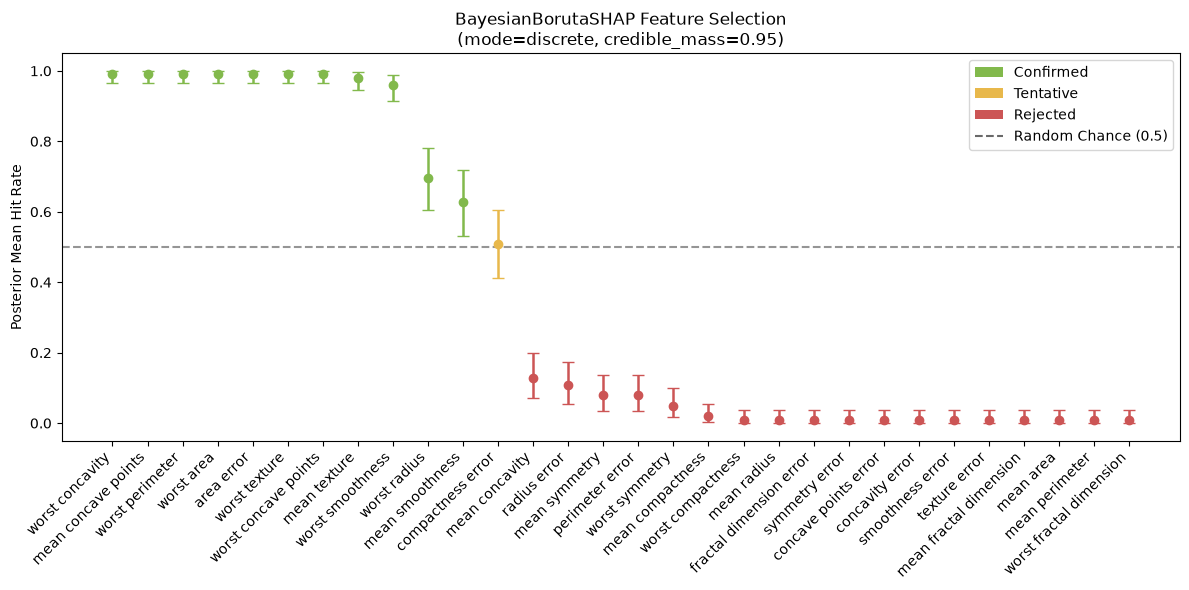

In [5]:
# Visualize selection results (Mean and CIs)
fig = selector.plot()

## 2. Global Non-Linear Selection: `BayesianPermutation`

`BayesianPermutation` is a model-agnostic feature selection tool that tracks importance using paired validation loss drops updated via the Student-t continuous engine.

In [22]:
from sklearn.ensemble import RandomForestClassifier

from bxai.selection import BayesianPermutation

# from sklearn.metrics import get_scorer_names
# get_scorer_names()


# Fit classifier
clf_perm = RandomForestClassifier(random_state=42, verbose=0).fit(X.values, y)

# Permutation feature selection with parallel jobs (n_jobs=2)
selector_perm = BayesianPermutation(
    model=clf_perm,
    scoring="adjusted_mutual_info_score",
    n_repeats=100,
    n_jobs=4,
    random_state=42,
    rope=(-0.001, 0.001),
)
selector_perm.fit(X, y)

print("Confirmed Features:", selector_perm.confirmed_)
selector_perm.summary().sort_values(
    by=["status", "mean"], ascending=[True, False]
).reset_index(drop=True)

Confirmed Features: ['mean texture', 'mean concave points', 'radius error', 'area error', 'compactness error', 'worst texture', 'worst area', 'worst smoothness', 'worst concave points']


,feature,status,mean,hdi_lower,hdi_upper,nu,alpha,beta
0,mean concave points,Confirmed,0.024274,0.021919,0.026630,100.0001,50.0001,0.007050
1,mean texture,Confirmed,0.021470,0.019520,0.023419,100.0001,50.0001,0.004829
2,worst texture,Confirmed,0.015705,0.014575,0.016836,100.0001,50.0001,0.001624
3,radius error,Confirmed,0.013941,0.012487,0.015394,100.0001,50.0001,0.002683
4,compactness error,Confirmed,0.013411,0.011890,0.014933,100.0001,50.0001,0.002940
5,worst concave points,Confirmed,0.013229,0.010978,0.015480,100.0001,50.0001,0.006436
6,worst area,Confirmed,0.012169,0.010012,0.014327,100.0001,50.0001,0.005913
7,area error,Confirmed,0.011647,0.009965,0.013329,100.0001,50.0001,0.003594
8,worst smoothness,Confirmed,0.005647,0.003990,0.007304,100.0001,50.0001,0.003488
9,mean radius,Rejected,0.000000,-0.000281,0.000281,100.0001,50.0001,0.000100


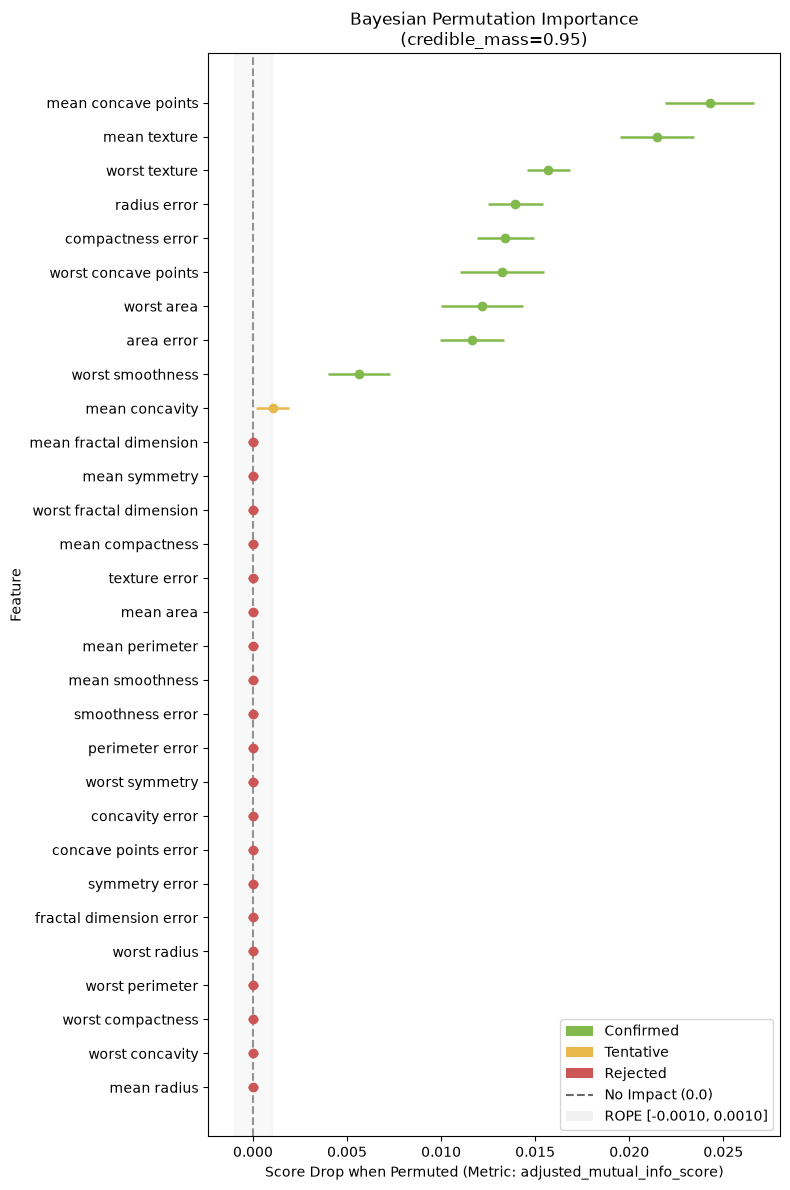

In [23]:
# Visualize permutation importance results (Mean and HDIs)
fig = selector_perm.plot(max_features=None)

## 3. Local Interpretability: `BayLIME`

`BayLIME` generates stable, prior-informed local explanations wrapping standard or custom perturbations in a Bayesian linear regression.

In [21]:
import lightgbm as lgb

from bxai.explanation import BayLIME

# 1. Fit the selector to get the priors
clf = lgb.LGBMClassifier(random_state=42, verbose=-1)

# 2. Instantiate BayLIME
explainer = BayLIME(training_data=X, feature_names=list(X.columns), backend="mcmc")

# 3. Fit the base model before explaining (since BorutaSHAP clones the model internally)
clf.fit(X, y)

# 4. Explain a single instance
explanation = explainer.explain_instance(
    instance=X.iloc[0].values, predict_fn=clf.predict_proba
)

explanation.as_dataframe().sort_values(by=["mean"])

/Users/sam/Locals Only/bxai/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [intercept, coefs, sigma_global]
Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 87 seconds.
There were 1876 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,feature,mean,std,hdi_lower,hdi_upper,value,backend
0,concave points error,-0.982068,0.006580,-0.988655,-0.975488,0.015870,mcmc
1,perimeter error,-0.774303,0.081589,-0.855916,-0.692731,8.589000,mcmc
2,smoothness error,-0.744614,0.146593,-0.891172,-0.598027,0.006399,mcmc
3,worst smoothness,-0.714487,0.077651,-0.792120,-0.636853,0.162200,mcmc
6,texture error,-0.631171,0.205074,-0.836199,-0.426129,0.905300,mcmc
8,concavity error,-0.552633,0.031755,-0.584394,-0.520886,0.053730,mcmc
12,mean compactness,-0.463662,0.389610,-0.853186,-0.074150,0.277600,mcmc
13,worst concave points,-0.454572,0.430724,-0.885191,-0.023951,0.265400,mcmc
17,symmetry error,-0.294902,0.030380,-0.325274,-0.264528,0.030030,mcmc
20,worst radius,-0.132683,0.045021,-0.177473,-0.080083,25.380000,mcmc


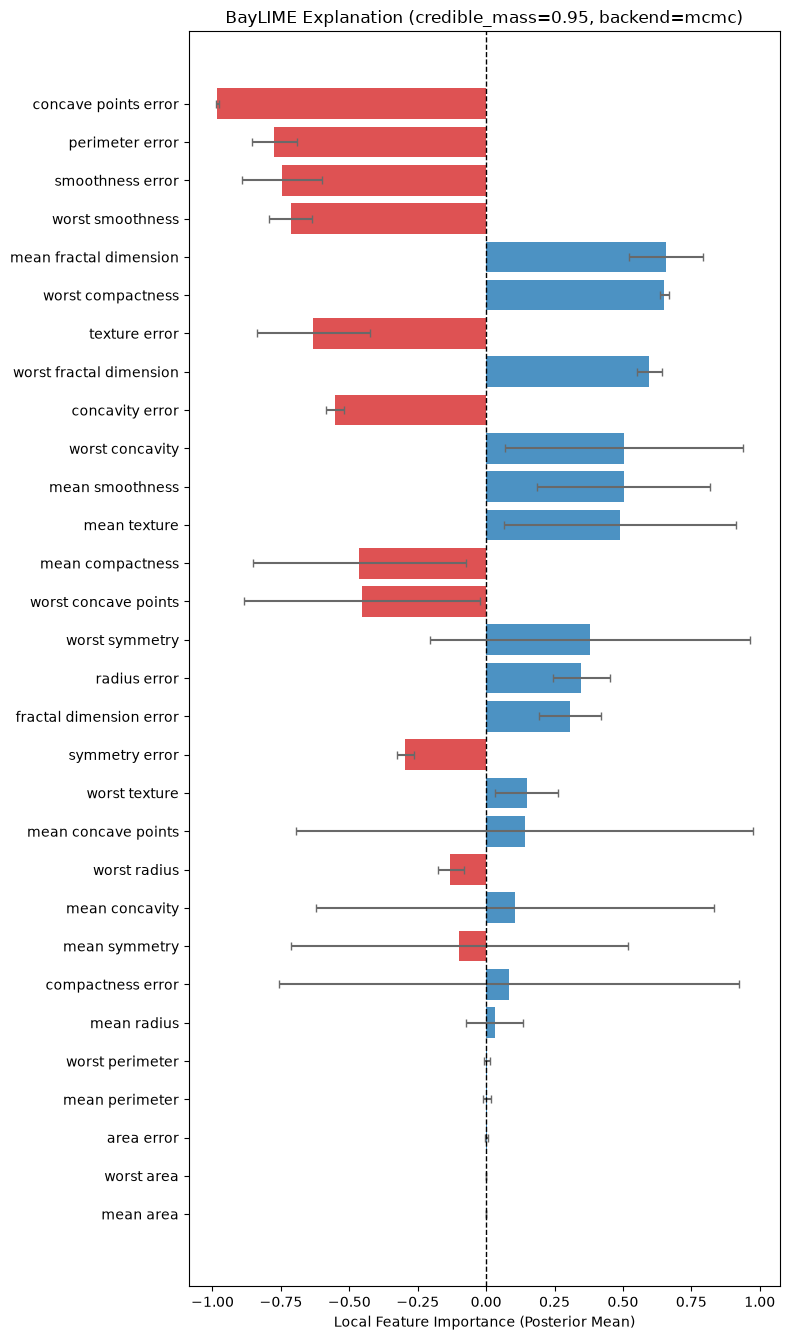

In [24]:
# Visualize the local explanation (comparing global prior vs local posterior)
fig = explanation.plot(max_features=None)

### Use BayesianBorutaSHAP Global Importance to build the Priors for BayLIME Local Importance

In [ ]:
import lightgbm as lgb

from bxai.explanation import BayLIME
from bxai.selection import BayesianBorutaSHAP

# 1. Fit the selector to get the priors
clf = lgb.LGBMClassifier(random_state=42, verbose=-1)
selector = BayesianBorutaSHAP(model=clf, mode="discrete", max_iter=100, random_state=42)
selector.fit(X, y)

# 2. Fit the original model so it can make predictions for the explainer
clf.fit(X, y)  # <-- ADD THIS LINE to fit clf on the data

# 3. Instantiate BayLIME with the priors
explainer = BayLIME(
    training_data=X,
    feature_names=list(X.columns),
    prior_mean=selector.feature_importances_,  # <-- Feeds the global SHAP priors here!
    prior_precision=1.0,  # Adjust the strength of the prior 0 to inf
    backend="mcmc",
)

# 4. Explain a single instance
explanation = explainer.explain_instance(
    instance=X.iloc[0].values, predict_fn=clf.predict_proba
)

explanation.as_dataframe().sort_values(by=["mean"])

/Users/sam/Locals Only/bxai/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/sam/Locals Only/bxai/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [intercept, coefs, sigma_global]
Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 244 seconds.
There were 983 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat

,feature,mean,std,hdi_lower,hdi_upper,value,backend
8,texture error,-0.362452,0.354181,-0.732357,-0.008472,0.905300,mcmc
9,perimeter error,-0.327009,0.328564,-0.655483,0.005753,8.589000,mcmc
10,worst symmetry,-0.297487,0.246778,-0.544691,-0.050770,0.460100,mcmc
11,concave points error,-0.264505,0.335104,-0.600050,0.070517,0.015870,mcmc
19,symmetry error,-0.092631,0.069274,-0.161888,-0.023065,0.030030,mcmc
22,worst radius,-0.022558,0.029110,-0.051960,0.008355,25.380000,mcmc
23,compactness error,-0.015505,0.077509,-0.092995,0.062158,0.049040,mcmc
24,worst texture,-0.014877,0.011498,-0.026455,-0.001700,17.330000,mcmc
25,mean perimeter,-0.003012,0.004061,-0.007069,0.001412,122.800000,mcmc
26,worst perimeter,-0.002076,0.003045,-0.005146,0.001211,184.600000,mcmc


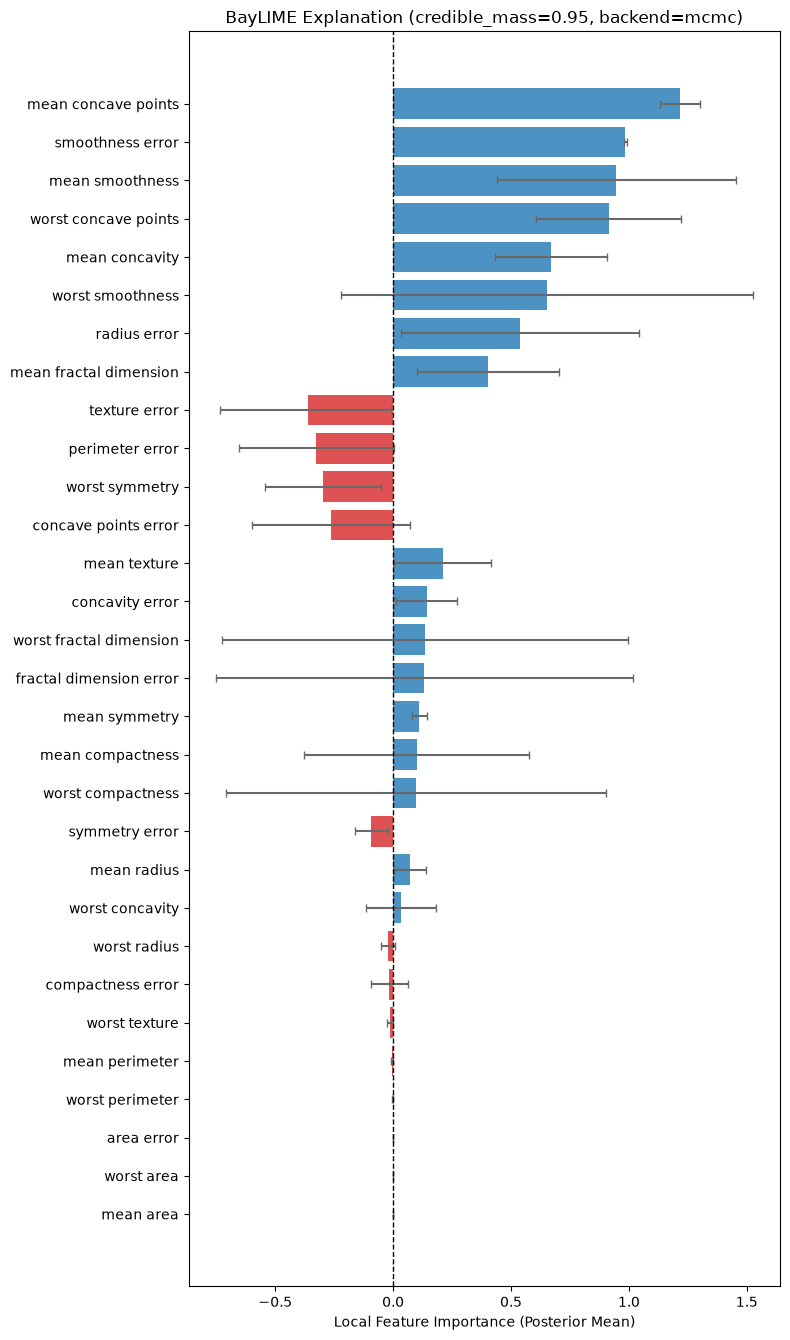

In [27]:
# Visualize the local explanation (comparing global prior vs local posterior)
fig = explanation.plot(max_features=None)

## 4. Parametric Selection: `ShrinkagePIP`

`ShrinkagePIP` implements high-dimensional generalized linear models (GLMs) using Horseshoe and Lasso regularizing priors, tracking Posterior Inclusion Probabilities (PIP) to select features.

### Horseshoe Prior

In [27]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

from bxai.parametric import ShrinkagePIP

# Scale the feature matrix
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Horseshoe prior — uses kappa-based PIP by default (pip_method="auto")
selector_hs = ShrinkagePIP(
    model_type="logistic",
    prior="horseshoe",
    kappa_threshold=0.5,  # k < 0.5 -> local scale dominates the signal
    pip_threshold=0.50,
    n_samples=1000,
    chains=4,
    random_state=42,
)
selector_hs.fit(X_scaled, y)

print("\nSelected features (Horseshoe):", selector_hs.confirmed_)
selector_hs.summary().sort_values(
    by=["selected", "mean"], ascending=[False, True]
).reset_index(drop=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, tau, lambdas, beta_raw]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 30 seconds.
There were 109 divergences after tuning. Increase `target_accept` or reparameterize.



Selected features (Horseshoe): ['mean concave points', 'radius error', 'area error', 'worst radius', 'worst texture', 'worst area', 'worst concave points', 'worst symmetry']


,feature,pip,pip_method,selected,mean,std,hdi_lower,hdi_upper,interval_type,kappa_mean
0,area error,0.73925,kappa,True,-4.519604,4.436431,-13.139832,1.135050,hdi,0.287253
1,worst area,0.65450,kappa,True,-3.915343,4.825262,-14.153374,1.651686,hdi,0.357779
2,worst texture,0.84225,kappa,True,-2.199366,1.040342,-4.040084,0.067338,hdi,0.267001
3,worst radius,0.54425,kappa,True,-1.843383,3.212823,-9.594993,2.153303,hdi,0.463546
4,worst concave points,0.62300,kappa,True,-1.653758,1.577239,-5.003978,0.532720,hdi,0.414326
5,mean concave points,0.53700,kappa,True,-1.401896,1.762182,-5.457041,0.885421,hdi,0.476952
6,radius error,0.55225,kappa,True,-1.304004,1.934972,-5.665913,1.581931,hdi,0.465840
7,worst symmetry,0.50050,kappa,True,-0.932867,0.725064,-2.389436,0.223190,hdi,0.507897
8,worst concavity,0.48775,kappa,False,-1.039143,1.244321,-3.798035,0.652537,hdi,0.519295
9,mean concavity,0.45325,kappa,False,-0.918092,1.366189,-3.913236,1.107486,hdi,0.546478


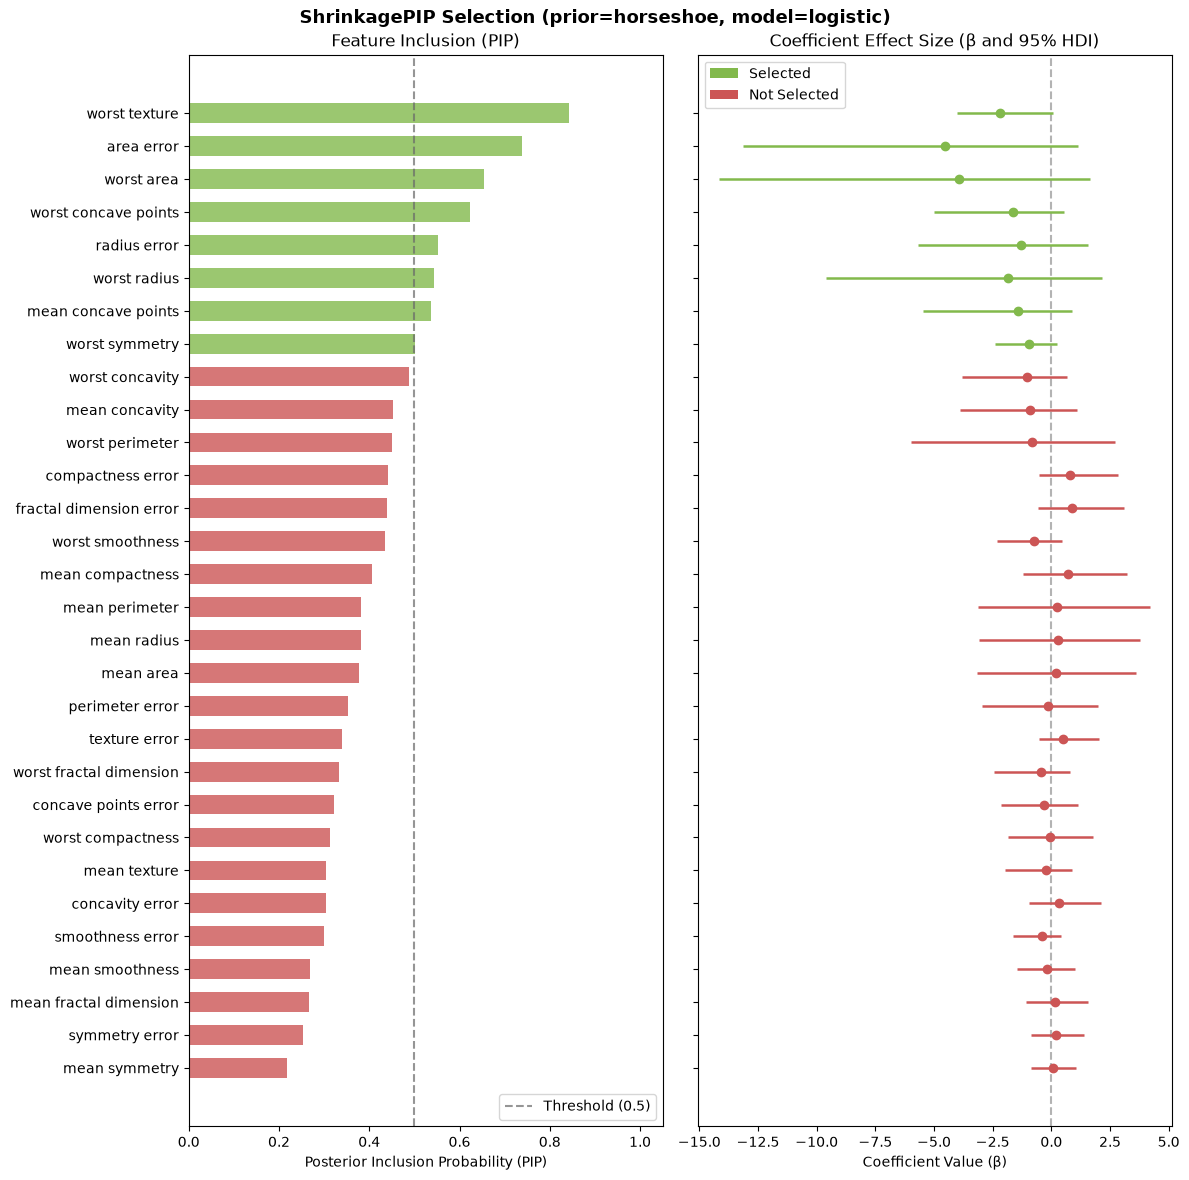

In [28]:
# Visualize the PIP and Coeff Effect Size
fig = selector_hs.plot(max_features=None)

### LASSO Prior

In [39]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Scale the feature matrix
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Lasso prior — uses auto-scaled |B| threshold (epsilon = 0.1) by default which may be too low
selector_lasso = ShrinkagePIP(
    model_type="logistic",
    prior="lasso",
    pip_threshold=0.7,
    epsilon=0.5,
    n_samples=1000,
    chains=4,
    random_state=42,
)
selector_lasso.fit(X_scaled, y)
print(f"\nEffective epsilon: {selector_lasso.epsilon_:.4f}")
print("\nSelected features (LASSO):", selector_lasso.confirmed_)
selector_lasso.summary().sort_values(
    by=["selected", "mean"], ascending=[False, True]
).reset_index(drop=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, b, beta]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.



Effective epsilon: 0.5000

Selected features (LASSO): ['mean concavity', 'mean concave points', 'radius error', 'area error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concavity', 'worst concave points', 'worst symmetry']


,feature,pip,pip_method,selected,mean,std,hdi_lower,hdi_upper,interval_type,epsilon
0,area error,0.81400,threshold,True,-2.524610,2.690099,-8.355124,1.669311,hdi,0.5
1,worst texture,0.97200,threshold,True,-2.305470,1.049724,-4.324874,-0.258303,hdi,0.5
2,radius error,0.85375,threshold,True,-2.145662,1.790668,-5.900814,0.642904,hdi,0.5
3,worst area,0.78800,threshold,True,-2.047554,2.475264,-7.360965,2.003799,hdi,0.5
4,worst radius,0.77075,threshold,True,-1.818744,2.234954,-6.645355,1.671920,hdi,0.5
5,mean concave points,0.77225,threshold,True,-1.506698,1.483963,-4.645130,0.950777,hdi,0.5
6,worst concave points,0.76450,threshold,True,-1.380632,1.333436,-4.137219,0.930527,hdi,0.5
7,mean concavity,0.73125,threshold,True,-1.316208,1.487266,-4.433964,1.193181,hdi,0.5
8,worst concavity,0.75000,threshold,True,-1.215085,1.249591,-3.821994,0.956958,hdi,0.5
9,worst symmetry,0.82650,threshold,True,-1.203408,0.768287,-2.656808,0.232529,hdi,0.5


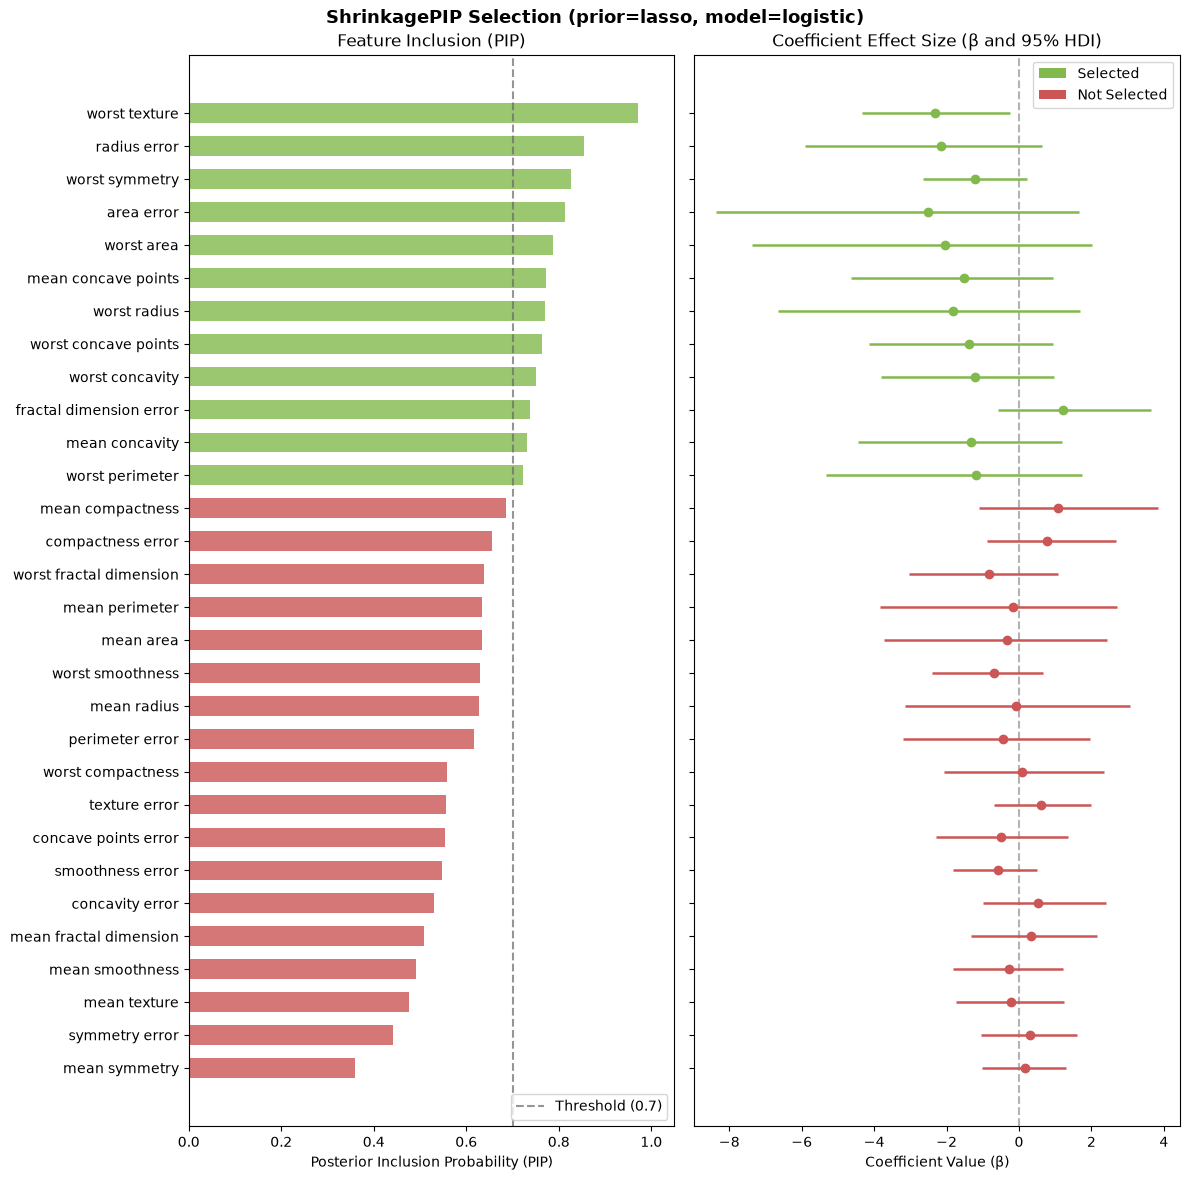

In [40]:
# Visualize the PIP and Coeff Effect Size
fig = selector_lasso.plot(max_features=None)

## 5. Native Bayesian Importance: `BARTImportance`

`BARTImportance` tracks Variable Inclusion Frequencies (VIF) from native Bayesian Additive Regression Trees (BART) models to estimate feature importance.

In [ ]:
from bxai.parametric import BARTImportance

# Classification example (Probit BART)
bart_clf = BARTImportance(
    model_type="classification",
    n_trees=200,  # Higher tree count ensures important features are split in every draw
    n_samples=500,
    credible_mass=0.80,  # 80% credible mass is a standard choice when n_trees is higher
    baseline_frequency=0.01,  # Low threshold
    tune=400,  # Moderate tuning steps to ensure convergence without taking too long
    chains=4,
    random_state=42,
)
bart_clf.fit(X, y)
print("\nClassification Selected features:", bart_clf.confirmed_)

Multiprocess sampling (4 chains in 4 jobs)
PGBART: [mu]
Sampling 4 chains for 400 tune and 500 draw iterations (1_600 + 2_000 draws total) took 45 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Classification Selected features: ['mean texture', 'mean concave points', 'area error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst concavity', 'worst concave points']


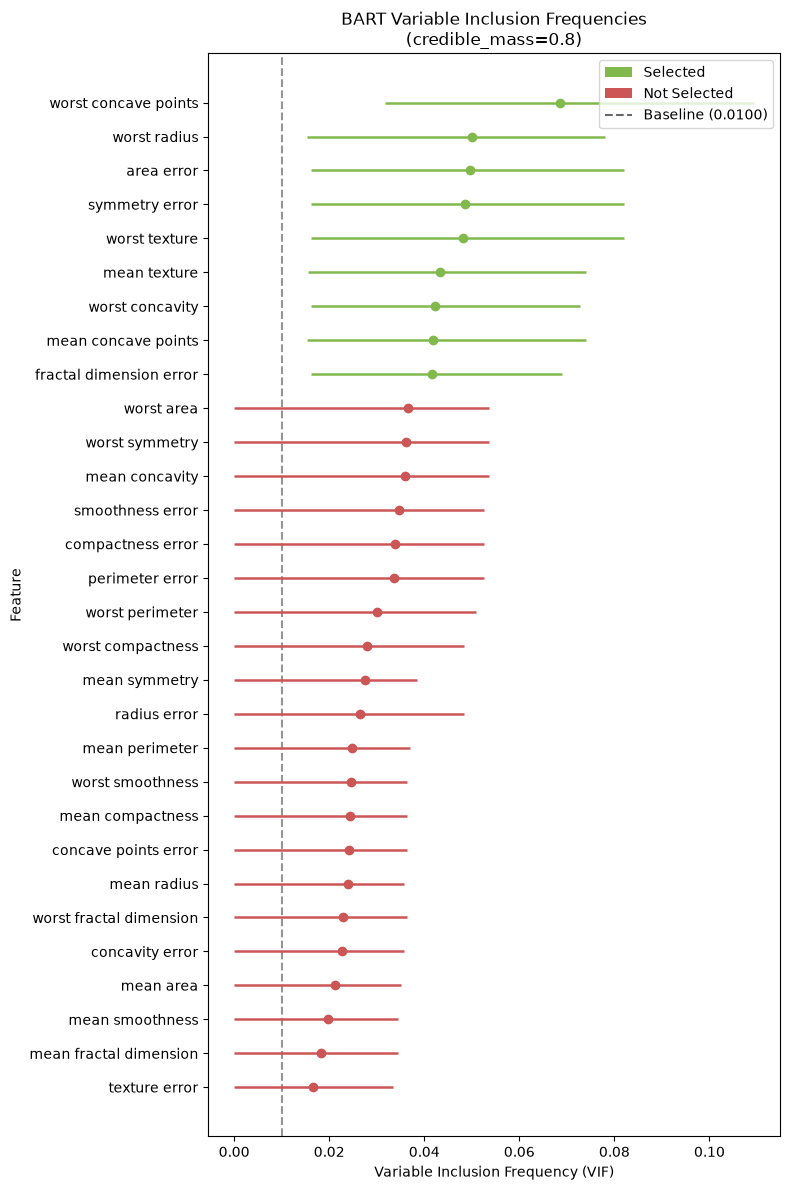

In [34]:
# Visualize VIF posterior means and credible intervals
fig = bart_clf.plot(max_features=None)